# Notebook 1 — Data Loading, Cleaning & Exploration

**Project**: Replication of *"Autoencoder Market Models for Interest Rates"* (Sokol, 2022)

This notebook performs the very first step of the pipeline: it ingests the raw Bloomberg
OIS / swap data, checks it for quality issues, and produces a single clean pickle file
that every downstream notebook (NS/NSS fits, VAE training, comparison, AEMM, trading)
will consume.

**Pipeline of this notebook:**
1. Load Bloomberg OIS/swap rates for **8 currencies**: USD, EUR, GBP, JPY, AUD, CAD, CHF, DKK.
2. Extract the **7 key tenors** used by Sokol (2022): 2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y.
3. Diagnose **data availability** per (currency, tenor) on a business-day calendar.
4. Forward-fill **small gaps** (≤ 3 business days — local holidays) to recover clean series.
5. Find the **longest contiguous common date range** across all currencies and all tenors.
6. Visualise historical swap curves (replicates Figure 8 of the paper) and curve-shape factors.
7. Save everything to `clean_swap_data.pkl`.

### Why the gap handling matters
In earlier iterations of this notebook we noticed that Bloomberg series sometimes
have *hidden* gaps: days missing from the index (not NaN, just absent). Those gaps
are often local public holidays (e.g. 4th of July for USD, Golden Week for JPY).
A naive `intersection` of dates works, but it silently throws away observations and
makes it very hard to see what we lost. We instead:

- Reindex every series onto a business-day calendar (exposes the missing dates as NaN).
- Forward-fill gaps up to 3 bdays (holidays have minimal impact on yield curves).
- Find the **longest contiguous run of dates for which every currency and every tenor
  is present**. This is the strictest valid common range.
- Display a missing-data heatmap so the whole team can see exactly what is kept.


## 0 — Imports & Setup

In [51]:
import pickle
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap

warnings.filterwarnings("ignore")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1 — Configuration

The paper encodes **7 swap rates** with maturities **2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y**.

Each currency lives in its own sheet inside the Excel file. The sheet layout is:
- column 0: date (first column, may be named `Date` or `eod_date` depending on export)
- remaining columns: `"{TICKER} Curncy"` with the rate expressed as a **percentage**
  (e.g. `3.2112` means `3.2112 %`, we will convert it to decimal `0.032112`).


In [52]:
DATA_PATH = Path("data/data_bloomberg.xlsx")

# Excel format:
#   - one sheet per currency curve
#   - columns are of the form "{TICKER} Curncy"
#   - first column is "Date"

CURVE_CONFIG = {
    "USD": {
        "sheet": "USSO",
        "ticker_map": {
            2: "USSO2",
            3: "USSO3",
            5: "USSO5",
            10: "USSO10",
            15: "USSO15",
            20: "USSO20",
            30: "USSO30",
        },
    },
    "EUR": {
        "sheet": "EUSWE",
        "ticker_map": {
            2: "EUSWE2",
            3: "EUSWE3",
            5: "EUSWE5",
            10: "EUSWE10",
            15: "EUSWE15",
            20: "EUSWE20",
            30: "EUSWE30",
        },
    },
    "GBP": {
        "sheet": "BPSWS",
        "ticker_map": {
            2: "BPSWS2",
            3: "BPSWS3",
            5: "BPSWS5",
            10: "BPSWS10",
            15: "BPSWS15",
            20: "BPSWS20",
            30: "BPSWS30",
        },
    },
    "JPY": {
        "sheet": "JYSO",
        "ticker_map": {
            2: "JYSO2",
            3: "JYSO3",
            5: "JYSO5",
            10: "JYSO10",
            15: "JYSO15",
            20: "JYSO20",
            30: "JYSO30",
        },
    },
    "AUD": {
        "sheet": "ADSO",
        "ticker_map": {
            2: "ADSO2",
            3: "ADSO3",
            5: "ADSO5",
            10: "ADSO10",
            15: "ADSO15",
            20: "ADSO20",
            30: "ADSO30",
        },
    },
    "CAD": {
        "sheet": "CDSO",
        "ticker_map": {
            2: "CDSO2",
            3: "CDSO3",
            5: "CDSO5",
            10: "CDSO10",
            15: "CDSO15",
            20: "CDSO20",
            30: "CDSO30",
        },
    },
    "CHF": {
        "sheet": "CKSWO",
        "ticker_map": {
            2: "CKSWO2",
            3: "CKSWO3",
            5: "CKSWO5",
            10: "CKSWO10",
            15: "CKSWO15",
            20: "CKSWO20",
            30: "CKSWO30",
        },
    },
    "DKK": {
        "sheet": "DKSW",
        "ticker_map": {
            2: "DKSW2",
            3: "DKSW3",
            5: "DKSW5",
            10: "DKSW10",
            15: "DKSW15",
            20: "DKSW20",
            30: "DKSW30",
        },
    },
}

TARGET_TENORS = [2, 3, 5, 10, 15, 20, 30]

In [53]:
# Forward-fill limit for isolated holiday gaps. 3 bdays covers every long weekend we
# are likely to see in developed markets.
FILL_LIMIT_BDAYS = 3

print(f"Currencies configured: {list(CURVE_CONFIG.keys())}")
print(f"Target tenors (years): {TARGET_TENORS}")
print(f"Forward-fill limit:    {FILL_LIMIT_BDAYS} business days")

Currencies configured: ['USD', 'EUR', 'GBP', 'JPY', 'AUD', 'CAD', 'CHF', 'DKK']
Target tenors (years): [2, 3, 5, 10, 15, 20, 30]
Forward-fill limit:    3 business days


## 2 — Load each currency sheet

`load_currency_curve` is the single point of contact with the Excel file. It:

1. Reads the sheet.
2. Parses the date column (handles `Date`, `eod_date`, or any first column).
3. Keeps only the 7 target-tenor columns (raises a clear error if any is missing).
4. Converts percentages to decimals (divides by 100).
5. Returns a `DataFrame` indexed by `Date`, with integer tenor columns
   `[2, 3, 5, 10, 15, 20, 30]` — this is the format the rest of the project expects.


In [54]:
def load_currency_curve(data_path: Path, ccy: str, curve_config: dict,
                        target_tenors: list[int]) -> pd.DataFrame:
    """
    Load one currency sheet from the Bloomberg Excel file.

    Returns a DataFrame indexed by Date, columns = target tenors (integers),
    values in decimal form (e.g. 0.032 for 3.2%).
    """
    sheet_name = curve_config[ccy]["sheet"]
    ticker_map = curve_config[ccy]["ticker_map"]

    df = pd.read_excel(data_path, sheet_name=sheet_name)
    df.columns = [str(c).strip() for c in df.columns]

    # The date column is always the first one, but its name varies ("Date", "eod_date", ...).
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce", dayfirst=True)
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

    # Select + rename the 7 tenor columns.
    keep = [date_col]
    rename_map = {}
    for tenor in target_tenors:
        full_col = f"{ticker_map[tenor]} Curncy"
        if full_col not in df.columns:
            raise KeyError(
                f"[{ccy}] column '{full_col}' missing in sheet '{sheet_name}'. "
                f"Available columns: {list(df.columns)}"
            )
        keep.append(full_col)
        rename_map[full_col] = tenor

    out = df[keep].rename(columns=rename_map).set_index(date_col)
    out.index.name = "Date"

    # Force numeric, convert % -> decimal.
    out = out.apply(pd.to_numeric, errors="coerce") / 100.0

    return out

In [55]:
# Load whatever is available and keep track of what we could not find.
swap_data: dict[str, pd.DataFrame] = {}
missing_sheets: list[str] = []

try:
    available_sheets = set(pd.ExcelFile(DATA_PATH).sheet_names)
except FileNotFoundError:
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Place the Bloomberg Excel file at this path "
        f"and re-run the cell."
    )

for ccy, cfg in CURVE_CONFIG.items():
    if cfg["sheet"] not in available_sheets:
        print(f"  [skip] {ccy}: sheet '{cfg['sheet']}' not found in Excel file")
        missing_sheets.append(ccy)
        continue
    try:
        swap_data[ccy] = load_currency_curve(DATA_PATH, ccy, CURVE_CONFIG, TARGET_TENORS)
        df = swap_data[ccy]
        print(f"  [ok]   {ccy}: {len(df):>5d} obs  "
              f"{df.index.min().date()} -> {df.index.max().date()}")
    except KeyError as e:
        print(f"  [skip] {ccy}: {e}")
        missing_sheets.append(ccy)

# The list of currencies we will actually use downstream.
CURRENCIES = list(swap_data.keys())
print(f"\nLoaded {len(CURRENCIES)} currencies: {CURRENCIES}")
if missing_sheets:
    print(f"Missing: {missing_sheets}  (notebook will still run on the available ones)")

  [ok]   USD:  6206 obs  2002-04-05 -> 2026-02-27
  [ok]   EUR:  4637 obs  2007-01-02 -> 2026-01-12
  [ok]   GBP:  6452 obs  2000-12-14 -> 2026-02-26
  [ok]   JPY:  5201 obs  2005-12-07 -> 2026-02-26
  [ok]   AUD:  5330 obs  2003-06-27 -> 2026-02-26
  [ok]   CAD:  4651 obs  2007-10-01 -> 2026-02-26
  [ok]   CHF:  6602 obs  2000-01-03 -> 2026-02-26
  [ok]   DKK:  6698 obs  2000-01-03 -> 2026-02-26

Loaded 8 currencies: ['USD', 'EUR', 'GBP', 'JPY', 'AUD', 'CAD', 'CHF', 'DKK']


## 3 — Per-(currency, tenor) availability diagnostic

We now build a **business-day calendar** that spans the union of all observed dates.
Reindexing every series onto this calendar makes hidden gaps visible as explicit
`NaN` cells, which is the only way to detect missing trading days.

For each (currency, tenor) pair we report:

- `first`, `last`: first and last non-NaN date
- `n_valid`:       number of valid observations on the business-day calendar
- `n_missing`:     number of business days where the rate is missing
- `max_gap_bd`:    the largest internal run of consecutive missing business days


In [56]:
# Master business-day calendar = bdays spanning the union of all observed dates.
all_observed = pd.Index([])
for df in swap_data.values():
    all_observed = all_observed.union(df.index)
bday_index = pd.bdate_range(all_observed.min(), all_observed.max())

print(f"Business-day calendar: {bday_index.min().date()} -> {bday_index.max().date()}")
print(f"Total business days:   {len(bday_index)}")

Business-day calendar: 2000-01-03 -> 2026-02-27
Total business days:   6825


In [57]:
def max_internal_gap_bd(series: pd.Series) -> int:
    """
    Return the length of the longest run of consecutive NaN values
    *strictly inside* the valid range [first_valid, last_valid] of the series.
    Leading / trailing NaNs (before/after the currency's active window) are ignored.
    """
    s = series.copy()
    if s.notna().sum() == 0:
        return 0
    first = s.first_valid_index()
    last  = s.last_valid_index()
    inner = s.loc[first:last]
    is_nan = inner.isna().values
    # Find runs of True.
    if not is_nan.any():
        return 0
    padded = np.r_[False, is_nan, False]
    d = np.diff(padded.astype(int))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    return int((ends - starts).max())

def availability_diagnostic(swap_data: dict, bday_index: pd.DatetimeIndex,
                            tenors: list[int]) -> pd.DataFrame:
    """Build the (currency, tenor) availability table on a business-day calendar."""
    rows = []
    for ccy, df in swap_data.items():
        df_bd = df.reindex(bday_index)
        for t in tenors:
            s = df_bd[t]
            valid = s.dropna()
            rows.append({
                "currency":  ccy,
                "tenor":     t,
                "first":     valid.index.min() if len(valid) else pd.NaT,
                "last":      valid.index.max() if len(valid) else pd.NaT,
                "n_valid":   int(valid.size),
                "n_missing": int(s.isna().sum()),
                "max_gap_bd": max_internal_gap_bd(s),
            })
    return pd.DataFrame(rows)

diag_raw = availability_diagnostic(swap_data, bday_index, TARGET_TENORS)
print("Raw availability (before any gap filling):")
print(diag_raw.to_string(index=False))

Raw availability (before any gap filling):
currency  tenor      first       last  n_valid  n_missing  max_gap_bd
     USD      2 2002-04-05 2026-02-27     6206        619           1
     USD      3 2002-04-05 2026-02-27     6206        619           1
     USD      5 2002-04-12 2026-02-27     6201        624           1
     USD     10 2010-04-07 2026-02-27     4118       2707           1
     USD     15 2011-10-26 2026-02-27     3714       3111           1
     USD     20 2011-12-23 2026-02-27     3672       3153           1
     USD     30 2011-11-29 2026-02-27     3690       3135           1
     EUR      2 2007-01-02 2026-01-12     4637       2188         280
     EUR      3 2007-02-13 2026-01-12     4607       2218         280
     EUR      5 2007-02-22 2026-01-12     4600       2225         280
     EUR     10 2007-01-29 2026-01-12     4618       2207         280
     EUR     15 2007-03-05 2026-01-12     4593       2232         280
     EUR     20 2007-03-06 2026-01-12     4592 

## 4 — Forward-fill small holiday gaps

Local public holidays (US Independence Day, Japanese Golden Week, UK bank holidays, ...)
show up as short NaN runs in the reindexed series. Carrying the previous observation
forward for **up to 3 business days** has essentially zero impact on curve dynamics
(rates do not move on holidays anyway) and recovers hundreds of otherwise unusable days.

Anything longer than 3 bdays is *not* filled: that would indicate a real data issue
worth investigating manually (extended outage, bad ticker, etc.).


In [58]:
def ffill_small_gaps(swap_data: dict, bday_index: pd.DatetimeIndex,
                     limit: int) -> dict:
    """Reindex each currency onto the bday calendar and forward-fill short gaps."""
    filled = {}
    for ccy, df in swap_data.items():
        filled[ccy] = df.reindex(bday_index).ffill(limit=limit)
    return filled

swap_data_bd        = {ccy: df.reindex(bday_index) for ccy, df in swap_data.items()}
swap_data_bd_filled = ffill_small_gaps(swap_data, bday_index, FILL_LIMIT_BDAYS)

diag_filled = availability_diagnostic(swap_data_bd_filled, bday_index, TARGET_TENORS)

# Report what was gained by filling.
gain = diag_filled["n_valid"].sum() - diag_raw["n_valid"].sum()
loss = diag_filled["n_missing"].sum()
print(f"Forward-fill gained {gain} (currency, tenor, bday) cells.")
print(f"Remaining missing cells after fill: {loss}")
print()
print("Per-series diagnostic after forward-fill:")
print(diag_filled.to_string(index=False))

Forward-fill gained 4615 (currency, tenor, bday) cells.
Remaining missing cells after fill: 110140

Per-series diagnostic after forward-fill:
currency  tenor      first       last  n_valid  n_missing  max_gap_bd
     USD      2 2002-04-05 2026-02-27     6236        589           0
     USD      3 2002-04-05 2026-02-27     6236        589           0
     USD      5 2002-04-12 2026-02-27     6231        594           0
     USD     10 2010-04-07 2026-02-27     4148       2677           0
     USD     15 2011-10-26 2026-02-27     3743       3082           0
     USD     20 2011-12-23 2026-02-27     3701       3124           0
     USD     30 2011-11-29 2026-02-27     3719       3106           0
     EUR      2 2007-01-02 2026-01-15     4691       2134         277
     EUR      3 2007-02-13 2026-01-15     4661       2164         277
     EUR      5 2007-02-22 2026-01-15     4654       2171         277
     EUR     10 2007-01-29 2026-01-15     4672       2153         277
     EUR     15 20

## 5 — Missing-data heatmap

One picture is worth a thousand diagnostics. Each row is a `(currency, tenor)` series,
each column is a business day, green = data present, red = data missing. The top panel
shows the raw availability and the bottom panel shows it after the short-gap fill.

This figure goes in the report appendix to justify the chosen common date range.


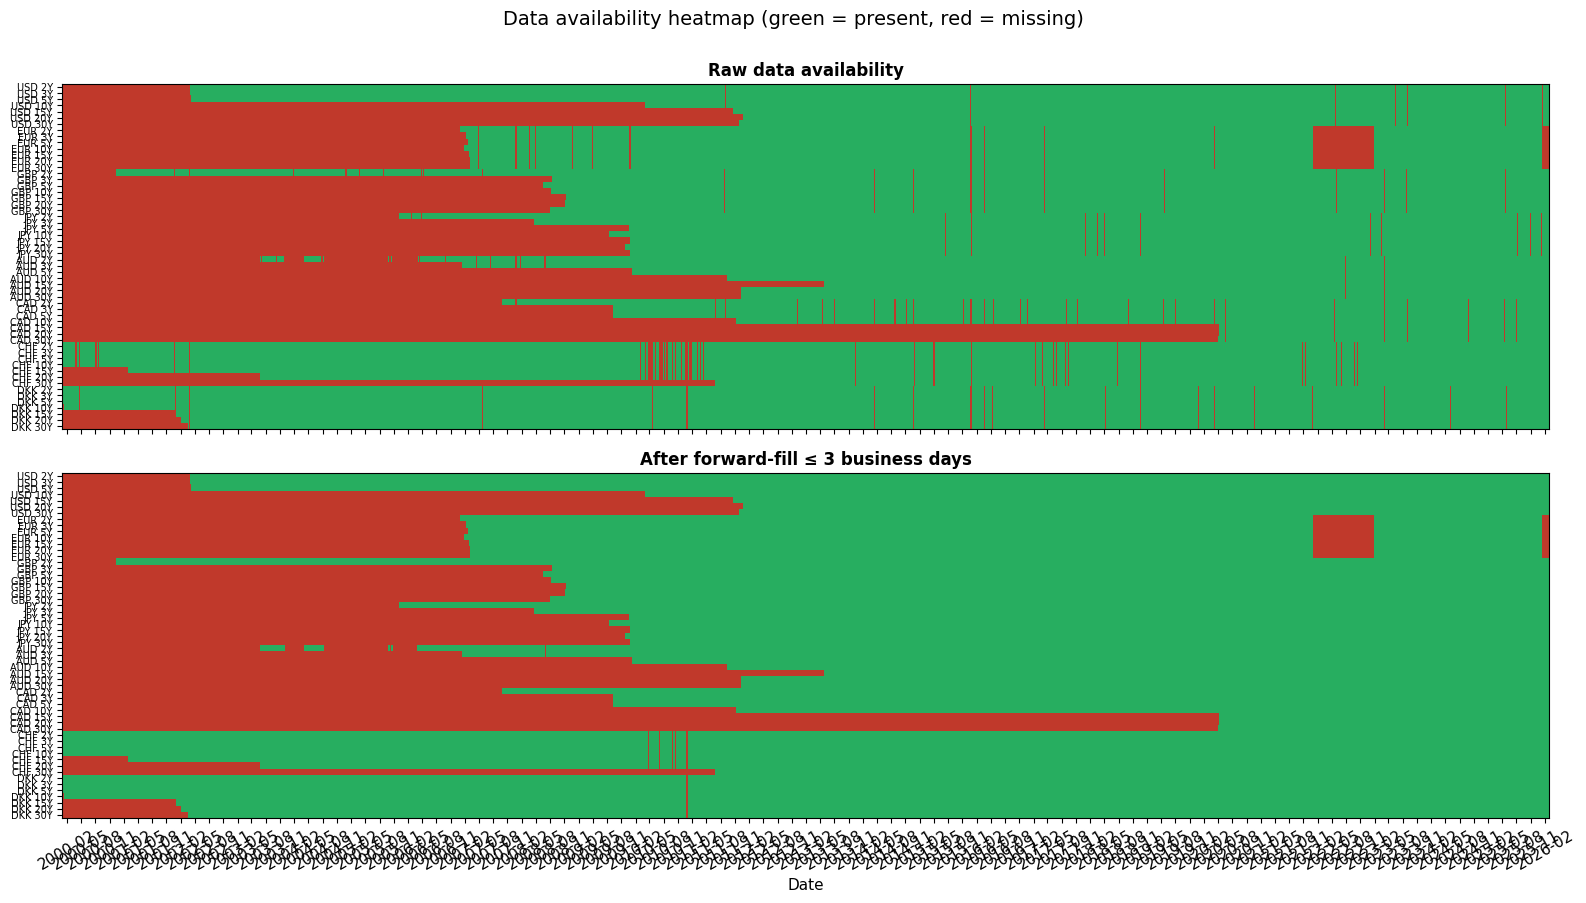

In [59]:
def presence_matrix(data: dict, bday_index: pd.DatetimeIndex,
                    tenors: list[int]) -> pd.DataFrame:
    """Rows = 'CCY tY' labels, columns = business days, values = 1 (present) / 0 (missing)."""
    rows, labels = [], []
    for ccy, df in data.items():
        for t in tenors:
            rows.append(df[t].notna().astype(int).values)
            labels.append(f"{ccy} {t}Y")
    return pd.DataFrame(np.array(rows), index=labels, columns=bday_index)

pres_raw    = presence_matrix(swap_data_bd,        bday_index, TARGET_TENORS)
pres_filled = presence_matrix(swap_data_bd_filled, bday_index, TARGET_TENORS)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
cmap = ListedColormap(["#c0392b", "#27ae60"])  # red = missing, green = present

for ax, mat, title in [
    (axes[0], pres_raw,    "Raw data availability"),
    (axes[1], pres_filled, f"After forward-fill ≤ {FILL_LIMIT_BDAYS} business days"),
]:
    dates_num = mdates.date2num(mat.columns.to_pydatetime())
    ax.imshow(
        mat.values, aspect="auto", cmap=cmap, vmin=0, vmax=1,
        extent=[dates_num[0], dates_num[-1], len(mat) - 0.5, -0.5],
        interpolation="nearest",
    )
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

axes[-1].set_xlabel("Date")
fig.suptitle("Data availability heatmap (green = present, red = missing)",
             fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01a_availability_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 — Longest common contiguous date range

This is the core of the cleaning logic. We want a single `[t_start, t_end]` interval
such that **every business day** in this interval has a valid observation for **every
currency and every tenor**. This is Interpretation A (the strictest, most rigorous option).

We also compute Interpretation B — the plain intersection of valid dates — and report
how many dates we lose by choosing A over B. In practice the two usually agree to
within a handful of dates.

### Algorithm
1. Build a boolean vector `all_valid[t] = True` iff every series has data on day `t`.
2. Find the longest run of consecutive `True` values. That run is the common range.


In [60]:
def longest_contiguous_true_run(mask: np.ndarray) -> tuple[int, int]:
    """Return (start_idx, end_idx_exclusive) of the longest True run in `mask`.
    Returns (0, 0) if there is no True."""
    if not mask.any():
        return 0, 0
    padded = np.r_[False, mask, False]
    d = np.diff(padded.astype(int))
    starts = np.where(d == 1)[0]
    ends   = np.where(d == -1)[0]
    lengths = ends - starts
    best = int(np.argmax(lengths))
    return int(starts[best]), int(ends[best])

# 'all_valid[t]' == True iff every series has a non-NaN value on business day t.
stacked = np.stack([
    swap_data_bd_filled[ccy][TARGET_TENORS].notna().all(axis=1).values
    for ccy in CURRENCIES
], axis=0)                          # shape: (n_ccy, n_bdays)
all_valid = stacked.all(axis=0)     # shape: (n_bdays,)

# Interpretation A — longest contiguous common run.
i0, i1 = longest_contiguous_true_run(all_valid)
common_start = bday_index[i0]
common_end   = bday_index[i1 - 1]
common_range = bday_index[i0:i1]

# Interpretation B — plain intersection (possibly non-contiguous).
intersection_dates = bday_index[all_valid]

print(f"Interpretation A — longest contiguous common run:")
print(f"  {common_start.date()}  ->  {common_end.date()}")
print(f"  length = {len(common_range)} business days")
print()
print(f"Interpretation B — intersection of valid business days:")
print(f"  n = {len(intersection_dates)} business days")
print(f"  range = {intersection_dates.min().date()} -> {intersection_dates.max().date()}")
print()
lost = len(intersection_dates) - len(common_range)
if lost == 0:
    print("Both interpretations agree perfectly: no internal gap inside the common run.")
else:
    print(f"Choosing A drops {lost} valid dates that fall outside the contiguous run.")
    print(f"(These are valid days separated from the main range by an unfilled gap.)")

Interpretation A — longest contiguous common run:
  2023-01-30  ->  2026-01-15
  length = 774 business days

Interpretation B — intersection of valid business days:
  n = 1208 business days
  range = 2020-05-08 -> 2026-01-15

Choosing A drops 434 valid dates that fall outside the contiguous run.
(These are valid days separated from the main range by an unfilled gap.)


## 7 — Build the final datasets

We now produce three objects that every downstream notebook will read from the pickle:

- **`swap_data`** — the untruncated per-currency history (after ffill). Useful for
  single-currency VAE training which does **not** require cross-currency alignment
  and benefits from the extra dates.
- **`swap_aligned`** — all currencies restricted to the **common contiguous range**.
  This is the dataset used by the multi-currency VAE, the CVAE, the NS/NSS benchmark
  and the trading backtest. Every currency here shares the exact same date index.
- **`df_multi`** — a long / stacked version of `swap_aligned` with a `currency` column.
  Convenient for pooled statistics and some plotting routines.


In [61]:
# (a) Per-currency, all available dates after ffill.
swap_data_final = {
    ccy: swap_data_bd_filled[ccy].dropna(how="any")     # drop any remaining NaN rows
    for ccy in CURRENCIES
}

# (b) Multi-currency aligned on the common contiguous range.
swap_aligned = {
    ccy: swap_data_bd_filled[ccy].loc[common_range].copy()
    for ccy in CURRENCIES
}

# Sanity check: every currency should be fully populated on the common range.
for ccy, df in swap_aligned.items():
    assert df.notna().all().all(), f"{ccy} still has NaNs on the common range!"
    assert len(df) == len(common_range), f"{ccy} has wrong length on the common range!"

# (c) Stacked multi-currency DataFrame (long format).
frames = []
for ccy, df in swap_aligned.items():
    tmp = df.copy()
    tmp.index.name = "Date"          # guarantee the index name
    tmp["currency"] = ccy
    frames.append(tmp.reset_index())
df_multi = (
    pd.concat(frames, axis=0, ignore_index=True)
      .sort_values(by=["Date", "currency"])
      .reset_index(drop=True)
)

print("Final datasets:")
for ccy, df in swap_data_final.items():
    print(f"  swap_data[{ccy}]:   shape={df.shape},  "
          f"{df.index.min().date()} -> {df.index.max().date()}")
print()
for ccy, df in swap_aligned.items():
    print(f"  swap_aligned[{ccy}]: shape={df.shape}")
print()
print(f"  df_multi: shape={df_multi.shape}")
print(f"\nCurrency distribution in df_multi:")
print(df_multi["currency"].value_counts().to_string())

Final datasets:
  swap_data[USD]:   shape=(3701, 7),  2011-12-23 -> 2026-02-27
  swap_data[EUR]:   shape=(4646, 7),  2007-03-06 -> 2026-01-15
  swap_data[GBP]:   shape=(4513, 7),  2008-11-12 -> 2026-02-27
  swap_data[JPY]:   shape=(4218, 7),  2009-12-30 -> 2026-02-27
  swap_data[AUD]:   shape=(3328, 7),  2013-05-29 -> 2026-02-27
  swap_data[CAD]:   shape=(1516, 7),  2020-05-08 -> 2026-02-27
  swap_data[CHF]:   shape=(3829, 7),  2011-06-28 -> 2026-02-27
  swap_data[DKK]:   shape=(6240, 7),  2002-03-22 -> 2026-02-27

  swap_aligned[USD]: shape=(774, 7)
  swap_aligned[EUR]: shape=(774, 7)
  swap_aligned[GBP]: shape=(774, 7)
  swap_aligned[JPY]: shape=(774, 7)
  swap_aligned[AUD]: shape=(774, 7)
  swap_aligned[CAD]: shape=(774, 7)
  swap_aligned[CHF]: shape=(774, 7)
  swap_aligned[DKK]: shape=(774, 7)

  df_multi: shape=(6192, 9)

Currency distribution in df_multi:
currency
AUD    774
CAD    774
CHF    774
DKK    774
EUR    774
GBP    774
JPY    774
USD    774


## 8 — Spaghetti plot (Figure 8 of Sokol 2022)

One panel per currency, every historical curve plotted as a faint line. The first
and last curves are highlighted for context. This figure is the paper's Figure 8
and is going straight into the report.


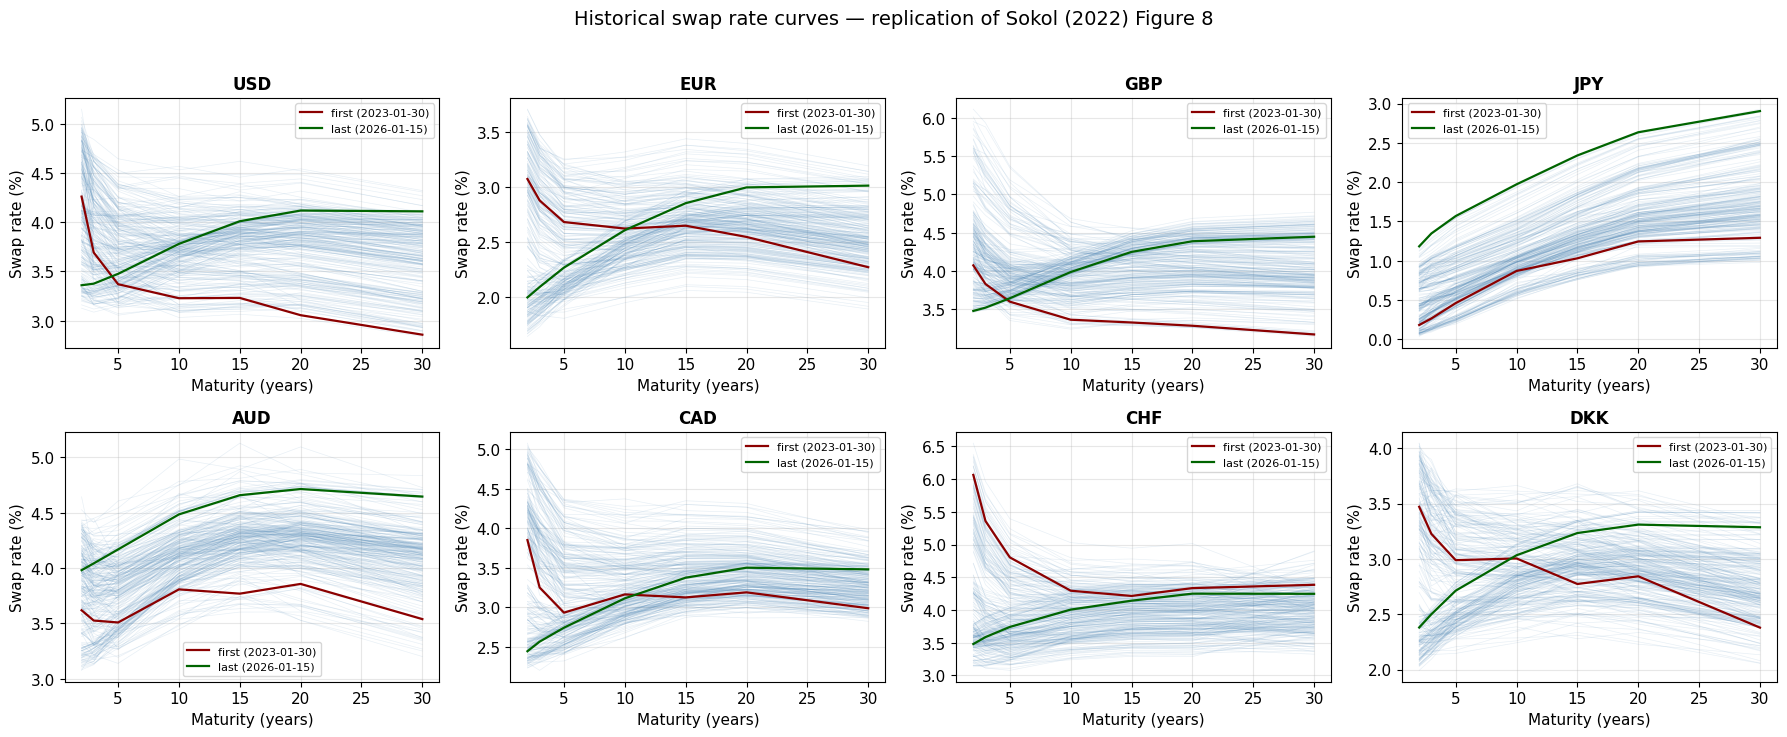

In [62]:
n_ccy = len(CURRENCIES)
n_cols = 4 if n_ccy >= 4 else n_ccy
n_rows = int(np.ceil(n_ccy / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.6 * n_rows),
                         sharey=False, squeeze=False)
axes = axes.flatten()

for ax, ccy in zip(axes, CURRENCIES):
    df = swap_aligned[ccy]
    tenors = np.array(df.columns, dtype=float)

    # faint background: all historical curves
    step = max(1, len(df) // 200)
    for i in range(0, len(df), step):
        ax.plot(tenors, 100.0 * df.iloc[i].values, alpha=0.12, linewidth=0.5,
                color="steelblue")

    ax.plot(tenors, 100.0 * df.iloc[0].values,  color="darkred",   linewidth=1.6,
            label=f"first ({df.index[0].date()})")
    ax.plot(tenors, 100.0 * df.iloc[-1].values, color="darkgreen", linewidth=1.6,
            label=f"last ({df.index[-1].date()})")

    ax.set_title(f"{ccy}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Maturity (years)")
    ax.set_ylabel("Swap rate (%)")
    ax.legend(fontsize=8, loc="best")

# hide empty axes if any
for ax in axes[n_ccy:]:
    ax.set_visible(False)

fig.suptitle("Historical swap rate curves — replication of Sokol (2022) Figure 8",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01b_spaghetti.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Time series of selected tenors

A more "traditional" view of the data: time series of the 2Y / 5Y / 10Y / 30Y rates
for each currency, lets us see the big rates moves during the sample period.


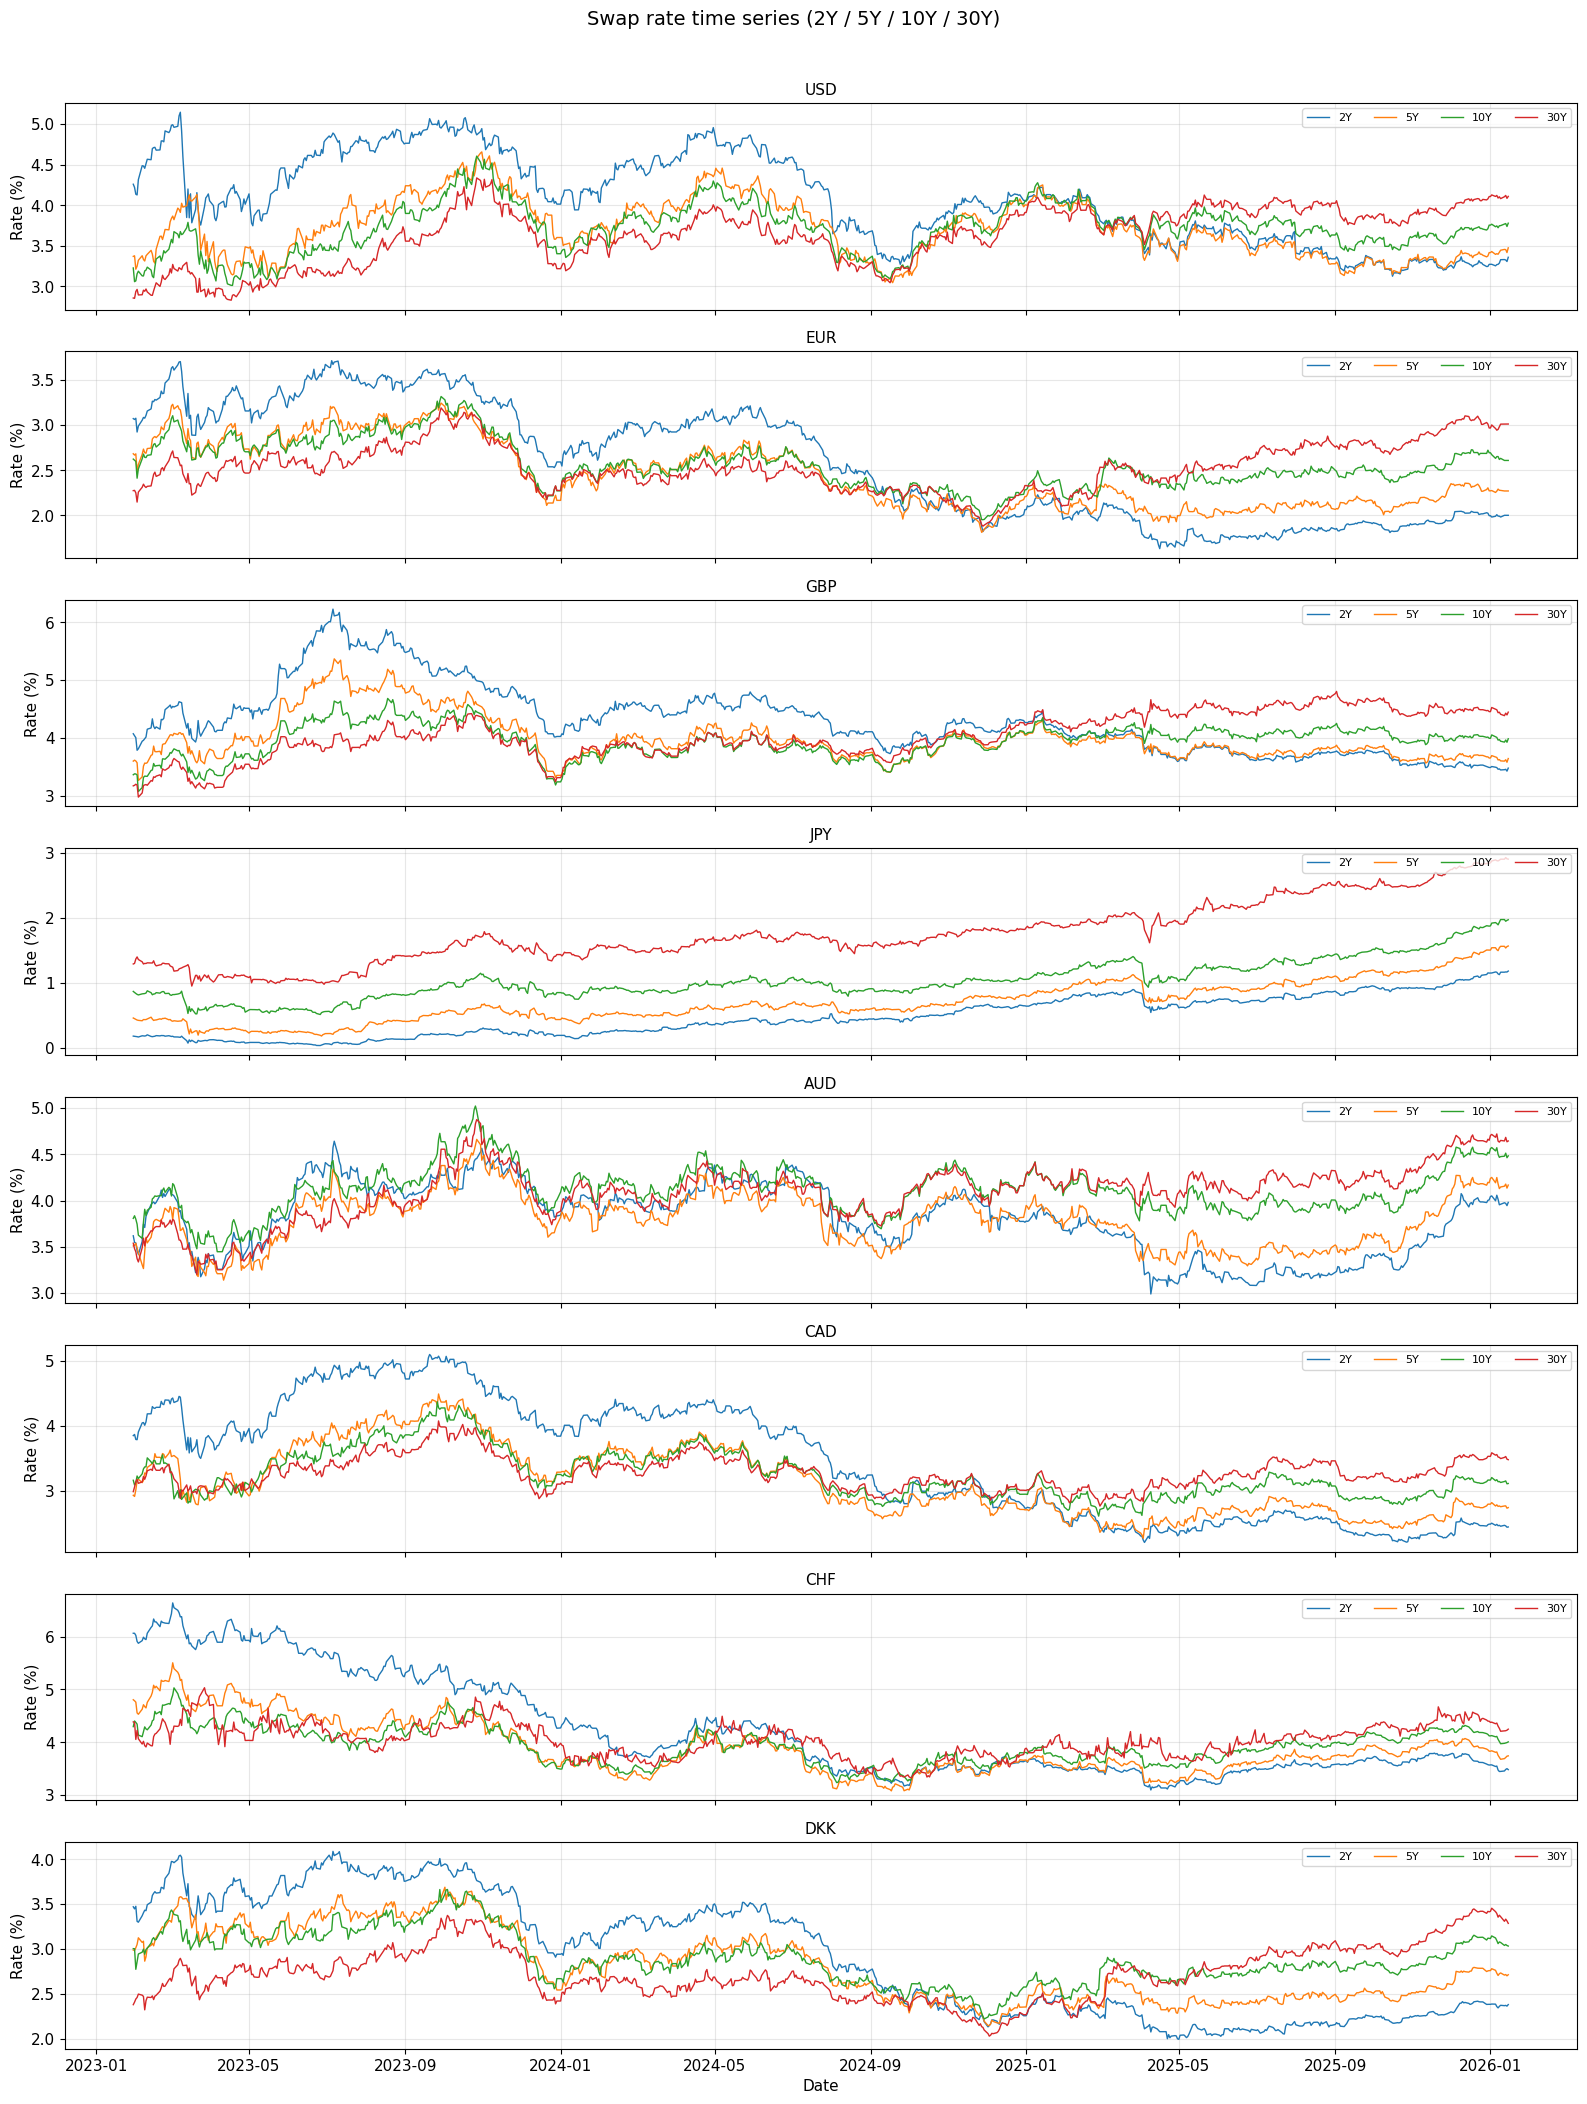

In [63]:
fig, axes = plt.subplots(n_ccy, 1, figsize=(16, 2.6 * n_ccy), sharex=True, squeeze=False)
axes = axes.flatten()

tenor_colors = {2: "tab:blue", 5: "tab:orange", 10: "tab:green", 30: "tab:red"}

for ax, ccy in zip(axes, CURRENCIES):
    df = swap_aligned[ccy]
    for tenor in [2, 5, 10, 30]:
        ax.plot(df.index, 100.0 * df[tenor], label=f"{tenor}Y",
                linewidth=1.0, color=tenor_colors[tenor])
    ax.set_ylabel("Rate (%)")
    ax.set_title(f"{ccy}", fontsize=11)
    ax.legend(loc="upper right", ncol=4, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

axes[-1].set_xlabel("Date")
fig.suptitle("Swap rate time series (2Y / 5Y / 10Y / 30Y)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01c_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 — Curve-shape proxies: level, slope, curvature

These are classical proxies that mimic the three Nelson-Siegel factors without any
fitting. They are purely descriptive and will help us later to check that the VAE
latent dimensions have a meaningful interpretation.

- **Level**     = mean rate across the 7 tenors
- **Slope**     = 30Y − 2Y
- **Curvature** = 2·10Y − 2Y − 30Y (butterfly)


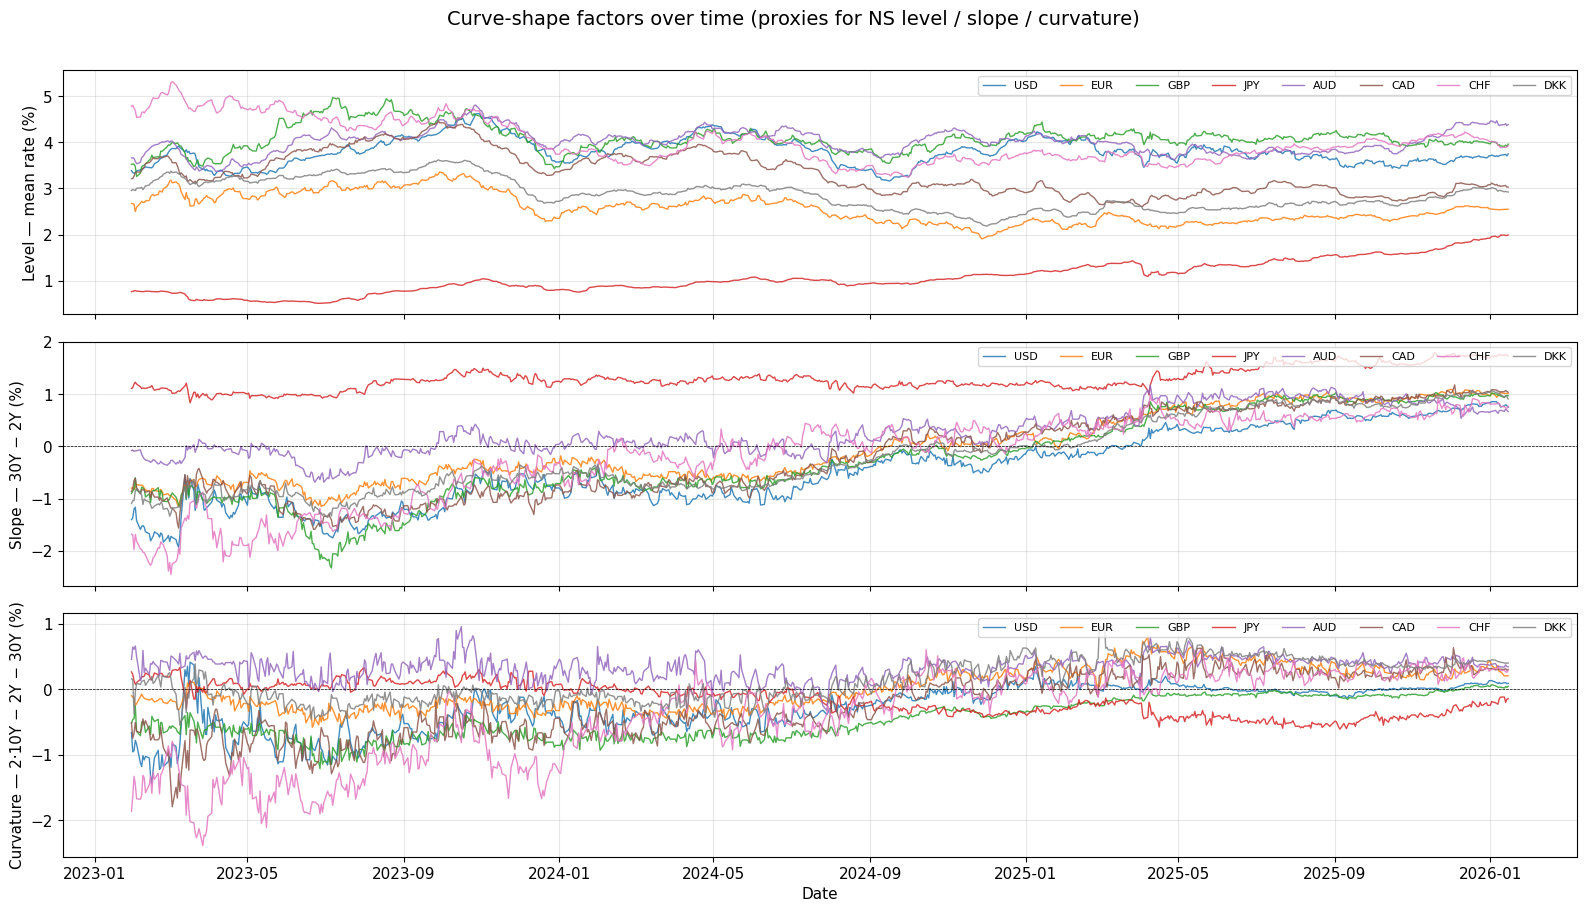

In [64]:
factor_analysis = {}
for ccy, df in swap_aligned.items():
    f = pd.DataFrame(index=df.index)
    f["level"]     = 100.0 * df.mean(axis=1)
    f["slope"]     = 100.0 * (df[30] - df[2])
    f["curvature"] = 100.0 * (2 * df[10] - df[2] - df[30])
    factor_analysis[ccy] = f

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
factor_labels = {
    "level":     "Level — mean rate (%)",
    "slope":     "Slope — 30Y − 2Y (%)",
    "curvature": "Curvature — 2·10Y − 2Y − 30Y (%)",
}

for ax, fname in zip(axes, ["level", "slope", "curvature"]):
    for ccy in CURRENCIES:
        ax.plot(factor_analysis[ccy].index, factor_analysis[ccy][fname],
                label=ccy, linewidth=1.0, alpha=0.85)
    ax.set_ylabel(factor_labels[fname])
    ax.legend(loc="upper right", ncol=len(CURRENCIES), fontsize=8)
    if fname != "level":
        ax.axhline(0, color="black", linewidth=0.5, linestyle="--")

axes[-1].set_xlabel("Date")
fig.suptitle("Curve-shape factors over time (proxies for NS level / slope / curvature)",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_01d_factors.png", dpi=150, bbox_inches="tight")
plt.show()

## 11 — Save the cleaned dataset

In [65]:
# Create data folder if needed
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 1. Save df_multi (le plus important)
df_multi.to_csv(DATA_DIR / "df_multi.csv", index=False)

In [66]:
print(f"\nFinal summary:")
print(f"  currencies:            {len(CURRENCIES)}  {CURRENCIES}")
print(f"  tenors:                {len(TARGET_TENORS)}  {TARGET_TENORS}")
print(f"  common date range:    {common_range.min().date()} -> {common_range.max().date()}")
print(f"  common range length:  {len(common_range)} business days")
print(f"  df_multi rows:        {len(df_multi)}")


Final summary:
  currencies:            8  ['USD', 'EUR', 'GBP', 'JPY', 'AUD', 'CAD', 'CHF', 'DKK']
  tenors:                7  [2, 3, 5, 10, 15, 20, 30]
  common date range:    2023-01-30 -> 2026-01-15
  common range length:  774 business days
  df_multi rows:        6192
